# Customer Churn Prediction using Machine Learning

## Business Problem

Customer churn significantly impacts profitability, customer acquisition costs, and long-term business growth.

The objective of this project is to identify customers likely to churn, understand the key factors influencing churn, and develop predictive models to support proactive retention strategies.

---

### Project Objectives

- Analyze customer behavior patterns associated with churn.
- Identify high-risk customer segments.
- Compare machine learning models for churn prediction.
- Translate model findings into actionable business recommendations.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from xgboost import XGBClassifier

import shap

## Dataset Overview

The Telco Customer Churn dataset contains customer demographics, subscription information, billing details, and service usage patterns.

Target Variable:

- **Churn**
    - Yes → Customer left the company.
    - No → Customer retained.

---
# 1. Data Preparation

In [2]:
# Load dataset
df = pd.read_csv('Telco-Customer-Churn.csv')

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.sample(5)

Dataset Shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2009,7639-OPLNG,Male,0,Yes,Yes,70,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),79.25,5731.85,No
844,3027-ZTDHO,Male,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.90,89.9,Yes
1027,6732-FZUGP,Female,0,No,No,47,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,One year,No,Credit card (automatic),94.90,4615.25,No
6482,5419-JPRRN,Male,0,No,No,1,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,101.45,101.45,Yes
2848,7508-KBIMB,Male,0,Yes,Yes,24,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,Yes,Credit card (automatic),56.25,1454.25,No


In [3]:
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

print("\nTarget Distribution:")

display(
    df['Churn']
    .value_counts()
    .to_frame()
)

Dataset Shape: 7043 rows × 21 columns

Target Distribution:


,count
Churn,
No,5174
Yes,1869


## Data Quality Assessment

In [4]:
# Check missing values & data types
print("Missing Values:")

display(
    df.isnull()
      .sum()
      .to_frame('Missing Values')
)

print("\nData Types:")

df.info()

Missing Values:


,Missing Values
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str   

## Data Cleaning

In [5]:
# Fix TotalCharges - convert to numeric, drop missing
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"\nMissing TotalCharges: {df['TotalCharges'].isnull().sum()}")
df = df.dropna(subset=['TotalCharges'])
print(f"Shape after cleaning: {df.shape}")


Missing TotalCharges: 11
Shape after cleaning: (7032, 21)


In [6]:
print(
    f"Remaining Missing Values: "
    f"{df.isnull().sum().sum()}"
)

print(
    f"Duplicate Records: "
    f"{df.duplicated().sum()}"
)

Remaining Missing Values: 0
Duplicate Records: 0


---
# 2. Exploratory Data Analysis (EDA)

In [7]:
sns.set_theme(
    style="whitegrid",
    context="talk",
    palette="crest"
)

plt.rcParams['figure.figsize'] = (12, 6)

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 2.1 Customer Churn Distribution

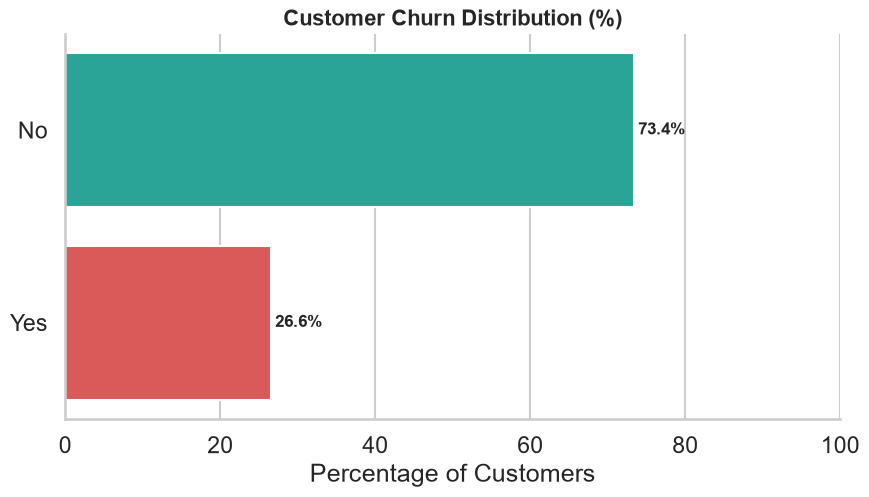

In [8]:
# Calculate churn percentages
churn_summary = (
    df['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

churn_summary.columns = ['Customer Status', 'Percentage']

# Plot
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=churn_summary,
    x='Percentage',
    y='Customer Status',
    palette=['#14b8a6', '#ef4444']
)

# Add labels
for i, value in enumerate(churn_summary['Percentage']):
    ax.text(
        value + 0.5,
        i,
        f'{value:.1f}%',
        va='center',
        fontsize=12,
        fontweight='bold'
    )

plt.title(
    'Customer Churn Distribution (%)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Percentage of Customers')

plt.ylabel('')

plt.xlim(0, 100)

sns.despine()

plt.show()

In [9]:
total_customers = len(df)

churned_customers = (
    df['Churn'] == 'Yes'
).sum()

retained_customers = (
    df['Churn'] == 'No'
).sum()

print(f"Total Customers: {total_customers:,}")

print(f"Customers Churned: {churned_customers:,}")

print(f"Customers Retained: {retained_customers:,}")

Total Customers: 7,032
Customers Churned: 1,869
Customers Retained: 5,163


### Business Insight

- Approximately **27% of customers have churned**, indicating a moderate retention challenge.
- Although the majority of customers remain retained, the churn rate is substantial enough to warrant proactive intervention strategies.
- Identifying characteristics of churned customers can support targeted retention campaigns and reduce revenue loss.

## 2.2 Contract-Based Churn Analysis

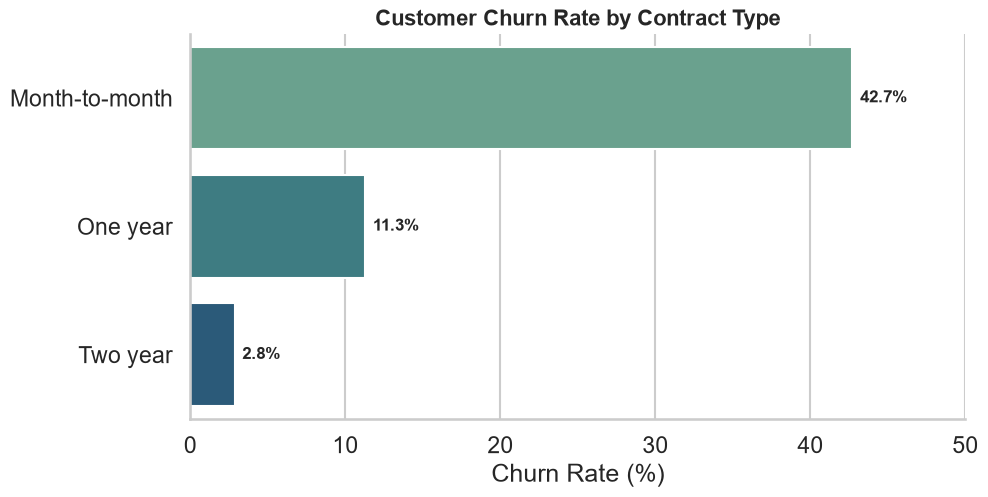

In [10]:
# Calculate churn rates
contract_churn = (
    df.groupby('Contract')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index()
)

contract_churn.columns = [
    'Contract Type',
    'Churn Rate (%)'
]

# Sort descending
contract_churn = contract_churn.sort_values(
    'Churn Rate (%)',
    ascending=False
)

# Plot
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=contract_churn,
    x='Churn Rate (%)',
    y='Contract Type',
    palette='crest'
)

# Add labels
for i, value in enumerate(
    contract_churn['Churn Rate (%)']
):
    ax.text(
        value + 0.5,
        i,
        f'{value:.1f}%',
        va='center',
        fontsize=12,
        fontweight='bold'
    )

plt.title(
    'Customer Churn Rate by Contract Type',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Churn Rate (%)')

plt.ylabel('')

plt.xlim(0, 50)

sns.despine()

plt.show()

In [11]:
contract_churn['Churn Rate (%)'] = (
    contract_churn['Churn Rate (%)']
    .round(2)
)

display(contract_churn)

,Contract Type,Churn Rate (%)
0,Month-to-month,42.71
1,One year,11.28
2,Two year,2.85


### Business Insight

- Customers subscribed to **month-to-month contracts exhibit the highest churn rates**.
- Churn decreases substantially among customers with **one-year and two-year contracts**.
- These findings suggest that encouraging customers to migrate toward longer-term agreements may improve retention outcomes.

## 2.3 Tenure Analysis

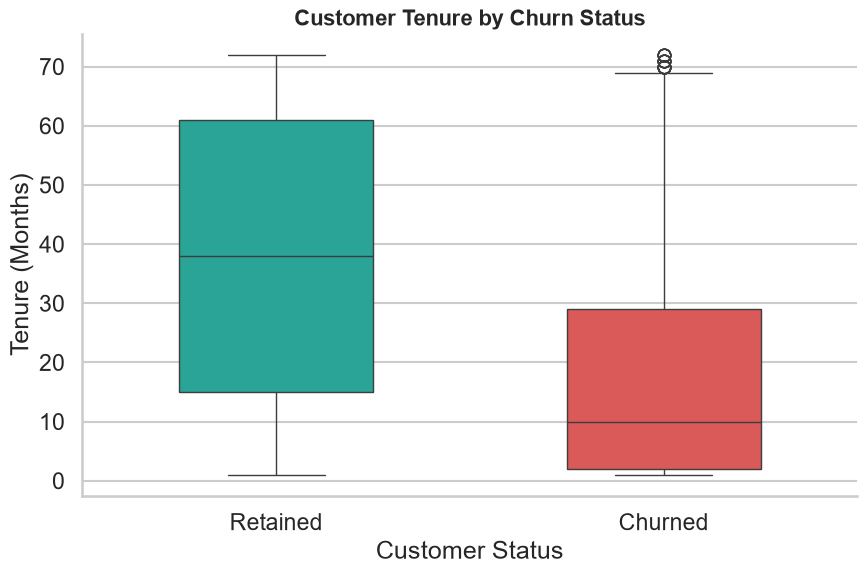

In [12]:
plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=df,
    x='Churn',
    y='tenure',
    palette=['#14b8a6', '#ef4444'],
    width=0.5
)

plt.title(
    'Customer Tenure by Churn Status',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Customer Status')

plt.ylabel('Tenure (Months)')

plt.xticks(
    [0, 1],
    ['Retained', 'Churned']
)

sns.despine()

plt.show()

In [13]:
tenure_summary = (
    df.groupby('Churn')['tenure']
      .agg([
          'mean',
          'median',
          'min',
          'max'
      ])
      .round(1)
)

display(tenure_summary)

,mean,median,min,max
Churn,,,,
No,37.7,38.0,1,72
Yes,18.0,10.0,1,72


In [14]:
df['Tenure Group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=[
        '< 1 Year',
        '1–2 Years',
        '2–4 Years',
        '4–6 Years'
    ]
)

tenure_churn = (
    df.groupby('Tenure Group')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index()
)

tenure_churn.columns = [
    'Tenure Group',
    'Churn Rate (%)'
]

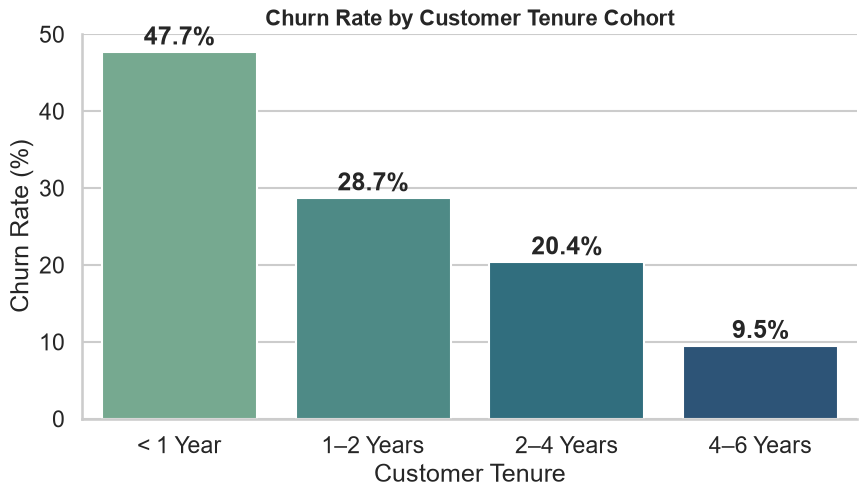

In [15]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=tenure_churn,
    x='Tenure Group',
    y='Churn Rate (%)',
    palette='crest'
)

for i, value in enumerate(
    tenure_churn['Churn Rate (%)']
):
    ax.text(
        i,
        value + 1,
        f'{value:.1f}%',
        ha='center',
        fontweight='bold'
    )

plt.title(
    'Churn Rate by Customer Tenure Cohort',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Customer Tenure')

plt.ylabel('Churn Rate (%)')

sns.despine()

plt.show()

### Business Insight

- Customers who churn generally exhibit **lower tenure values** compared to retained customers.
- The findings suggest that the **initial months of the customer lifecycle represent a critical retention period**.
- Organizations should prioritize onboarding experiences and early engagement initiatives to improve customer loyalty.

## 2.4 Monthly Charges Analysis

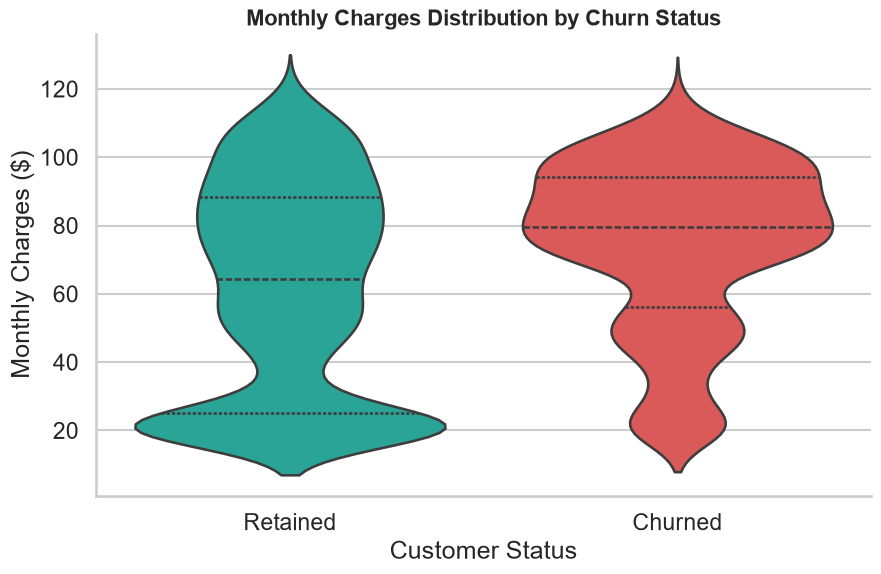

In [16]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='Churn',
    y='MonthlyCharges',
    palette=['#14b8a6', '#ef4444'],
    inner='quartile'
)

plt.title(
    'Monthly Charges Distribution by Churn Status',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Customer Status')

plt.ylabel('Monthly Charges ($)')

plt.xticks(
    [0, 1],
    ['Retained', 'Churned']
)

sns.despine()

plt.show()

### Summary Statistics

In [17]:
charges_summary = (
    df.groupby('Churn')['MonthlyCharges']
      .agg([
          'mean',
          'median',
          'min',
          'max'
      ])
      .round(2)
)

display(charges_summary)

,mean,median,min,max
Churn,,,,
No,61.31,64.45,18.25,118.75
Yes,74.44,79.65,18.85,118.35


### Price Tier Risk Analysis

In [18]:
df['Charge Tier'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 35, 70, 100, 120],
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

charge_risk = (
    df.groupby('Charge Tier')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index()
)

charge_risk.columns = [
    'Charge Tier',
    'Churn Rate (%)'
]

### Tier Visualization

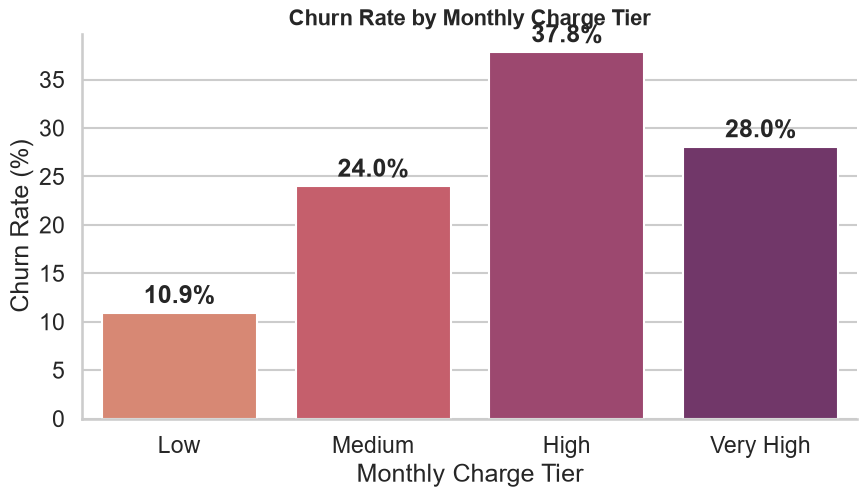

In [19]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=charge_risk,
    x='Charge Tier',
    y='Churn Rate (%)',
    palette='flare'
)

for i, value in enumerate(
    charge_risk['Churn Rate (%)']
):
    ax.text(
        i,
        value + 1,
        f'{value:.1f}%',
        ha='center',
        fontweight='bold'
    )

plt.title(
    'Churn Rate by Monthly Charge Tier',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Monthly Charge Tier')

plt.ylabel('Churn Rate (%)')

sns.despine()

plt.show()

### Business Insight

- Customers with **higher monthly charges exhibit elevated churn rates**.
- Premium pricing may increase customer expectations regarding service quality and perceived value.
- Organizations should closely monitor high-value customers and consider targeted retention strategies, such as loyalty programs or service enhancements.

## 2.5 Internet Service Risk Analysis

### Calculate Churn Rates

In [20]:
internet_risk = (
    df.groupby('InternetService')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index()
)

internet_risk.columns = [
    'Internet Service',
    'Churn Rate (%)'
]

internet_risk = internet_risk.sort_values(
    'Churn Rate (%)',
    ascending=False
)

### Visualization

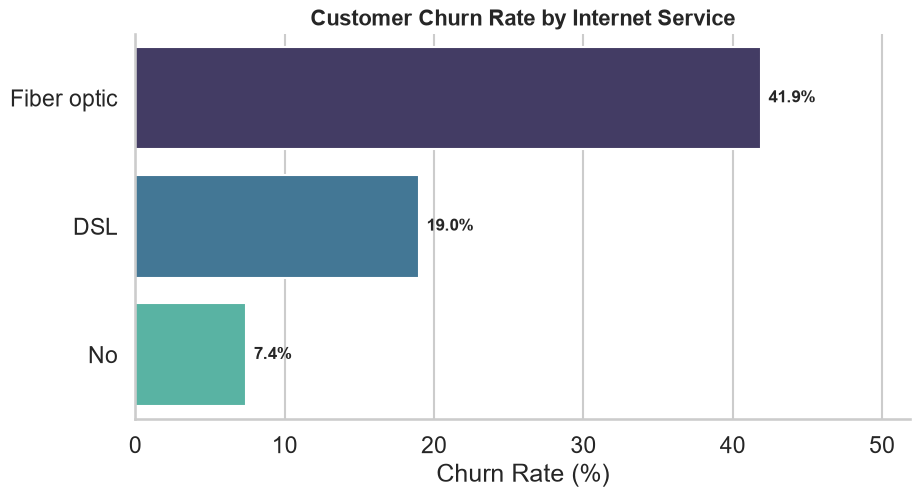

In [21]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=internet_risk,
    x='Churn Rate (%)',
    y='Internet Service',
    palette='mako'
)

# Add labels
for i, value in enumerate(
    internet_risk['Churn Rate (%)']
):
    ax.text(
        value + 0.5,
        i,
        f'{value:.1f}%',
        va='center',
        fontsize=12,
        fontweight='bold'
    )

plt.title(
    'Customer Churn Rate by Internet Service',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Churn Rate (%)')

plt.ylabel('')

plt.xlim(0, max(internet_risk['Churn Rate (%)']) + 10)

sns.despine()

plt.show()

### Summary Table

In [22]:
display(
    internet_risk.round(2)
)

,Internet Service,Churn Rate (%)
1,Fiber optic,41.89
0,DSL,19.00
2,No,7.43


### Business Insight

- Customers subscribed to **Fiber Optic internet services exhibit the highest churn rates**.
- Premium service offerings may lead to elevated customer expectations regarding quality and reliability.
- Organizations should investigate service quality concerns and strengthen retention initiatives for high-value internet subscribers.

## 2.6 Payment Method Risk Analysis

### Calculate Churn Rates

In [23]:
payment_risk = (
    df.groupby('PaymentMethod')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index()
)

payment_risk.columns = [
    'Payment Method',
    'Churn Rate (%)'
]

payment_risk = payment_risk.sort_values(
    'Churn Rate (%)',
    ascending=False
)

### Visualization

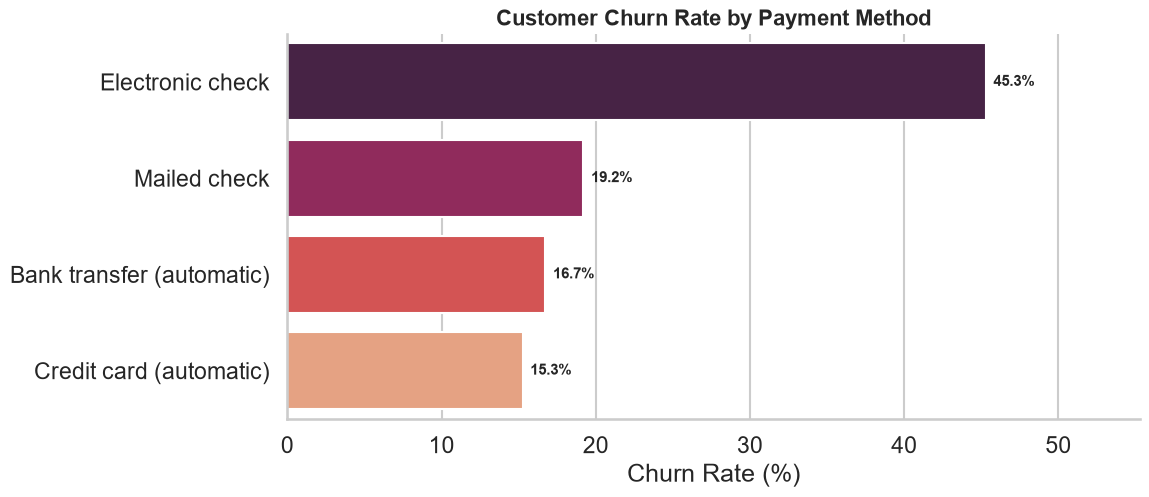

In [24]:
plt.figure(figsize=(11, 5))

ax = sns.barplot(
    data=payment_risk,
    x='Churn Rate (%)',
    y='Payment Method',
    palette='rocket'
)

for i, value in enumerate(
    payment_risk['Churn Rate (%)']
):
    ax.text(
        value + 0.5,
        i,
        f'{value:.1f}%',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'Customer Churn Rate by Payment Method',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Churn Rate (%)')

plt.ylabel('')

plt.xlim(
    0,
    payment_risk['Churn Rate (%)'].max() + 10
)

sns.despine()

plt.show()

### Summary Table

In [25]:
display(
    payment_risk.round(2)
)

,Payment Method,Churn Rate (%)
2,Electronic check,45.29
3,Mailed check,19.20
0,Bank transfer (automatic),16.73
1,Credit card (automatic),15.25


### Business Insight

- Customers using **Electronic Check** exhibit the highest churn rates among all payment methods.
- Automatic payment mechanisms, such as **bank transfers and credit card payments**, are associated with stronger customer retention.
- Promoting auto-pay enrollment may improve customer stickiness and reduce churn risk.

In [26]:
highest_risk = payment_risk.iloc[0]

print(
    f"Highest Risk Segment: "
    f"{highest_risk['Payment Method']}"
)

print(
    f"Churn Rate: "
    f"{highest_risk['Churn Rate (%)']:.2f}%"
)

Highest Risk Segment: Electronic check
Churn Rate: 45.29%


## 2.7 Customer Lifecycle Analysis

### Create Tenure Cohorts

In [27]:
df['Tenure Cohort'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=[
        '0–12 Months',
        '13–24 Months',
        '25–48 Months',
        '49–72 Months'
    ],
    include_lowest=True
)

### Calculate Churn Rates

In [28]:
tenure_risk = (
    df.groupby('Tenure Cohort')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index()
)

tenure_risk.columns = [
    'Tenure Cohort',
    'Churn Rate (%)'
]

### Visualization

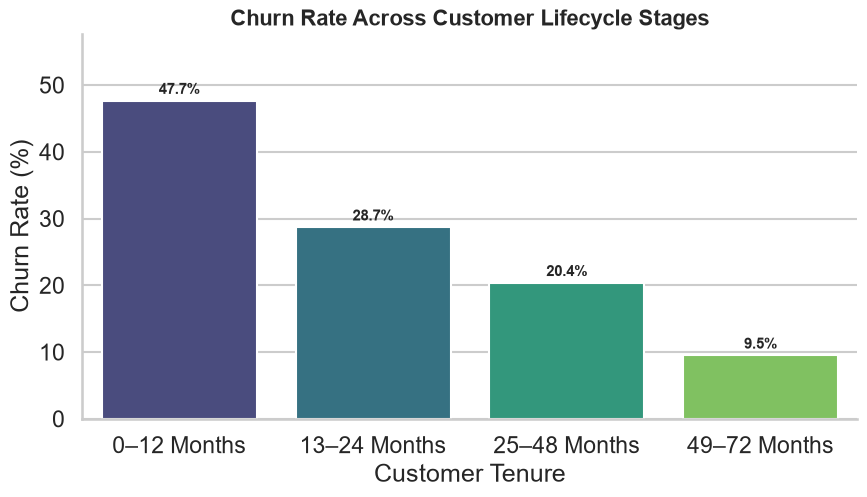

In [29]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=tenure_risk,
    x='Tenure Cohort',
    y='Churn Rate (%)',
    palette='viridis'
)

for i, value in enumerate(
    tenure_risk['Churn Rate (%)']
):
    ax.text(
        i,
        value + 1,
        f'{value:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'Churn Rate Across Customer Lifecycle Stages',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Customer Tenure')

plt.ylabel('Churn Rate (%)')

plt.ylim(
    0,
    tenure_risk['Churn Rate (%)'].max() + 10
)

sns.despine()

plt.show()

### Summary Table

In [30]:
display(
    tenure_risk.round(2)
)

,Tenure Cohort,Churn Rate (%)
0,0–12 Months,47.68
1,13–24 Months,28.71
2,25–48 Months,20.39
3,49–72 Months,9.51


### Highest Risk Cohort

In [31]:
highest_risk = tenure_risk.loc[
    tenure_risk['Churn Rate (%)'].idxmax()
]

print(
    f"Highest Risk Cohort: "
    f"{highest_risk['Tenure Cohort']}"
)

print(
    f"Churn Rate: "
    f"{highest_risk['Churn Rate (%)']:.2f}%"
)

Highest Risk Cohort: 0–12 Months
Churn Rate: 47.68%


### Business Insight

- Customers within their **first year of service exhibit the highest churn rates**.
- Churn propensity decreases substantially as tenure increases.
- The early customer lifecycle represents a critical period for onboarding, engagement, and proactive retention initiatives.

## 2.8 Pricing Risk Analysis

### Create Pricing Tiers

In [32]:
df['Pricing Tier'] = pd.cut(
    df['MonthlyCharges'],
    bins=[-1, 35, 70, 100, 120],
    labels=[
        'Low',
        'Medium',
        'High',
        'Premium'
    ]
)

### Calculate Churn Rates

In [33]:
pricing_risk = (
    df.groupby('Pricing Tier')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index()
)

pricing_risk.columns = [
    'Pricing Tier',
    'Churn Rate (%)'
]

### Visualization

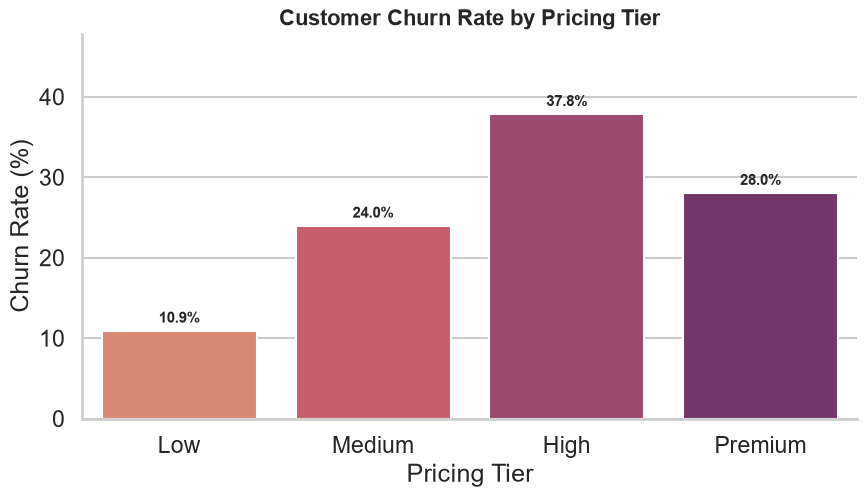

In [34]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=pricing_risk,
    x='Pricing Tier',
    y='Churn Rate (%)',
    palette='flare'
)

for i, value in enumerate(
    pricing_risk['Churn Rate (%)']
):
    ax.text(
        i,
        value + 1,
        f'{value:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'Customer Churn Rate by Pricing Tier',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Pricing Tier')

plt.ylabel('Churn Rate (%)')

plt.ylim(
    0,
    pricing_risk['Churn Rate (%)'].max() + 10
)

sns.despine()

plt.show()

### Summary Table

In [35]:
display(
    pricing_risk.round(2)
)

,Pricing Tier,Churn Rate (%)
0,Low,10.93
1,Medium,23.98
2,High,37.85
3,Premium,28.05


### Highest Risk Tier

In [36]:
highest_risk = pricing_risk.loc[
    pricing_risk['Churn Rate (%)'].idxmax()
]

print(
    f"Highest Risk Pricing Tier: "
    f"{highest_risk['Pricing Tier']}"
)

print(
    f"Churn Rate: "
    f"{highest_risk['Churn Rate (%)']:.2f}%"
)

Highest Risk Pricing Tier: High
Churn Rate: 37.85%


### Business Insight

- Customers paying **premium monthly charges demonstrate higher churn rates** compared to lower pricing segments.
- Higher-paying customers may possess elevated expectations regarding service quality and perceived value.
- Organizations should proactively monitor high-value customers and consider targeted loyalty initiatives to improve retention.

## 2.9 Demographic Drivers of Churn

### Create Risk Dataset

In [37]:
demographic_features = [
    'SeniorCitizen',
    'Partner',
    'Dependents'
]

demographic_results = []

for feature in demographic_features:

    risk = (
        df.groupby(feature)['Churn']
          .apply(lambda x: (x == 'Yes').mean() * 100)
          .reset_index()
    )

    risk.columns = [
        'Category',
        'Churn Rate (%)'
    ]

    risk['Feature'] = feature

    demographic_results.append(risk)

demographic_df = pd.concat(
    demographic_results,
    ignore_index=True
)

In [38]:
demographic_df['Category'] = (
    demographic_df['Category']
    .replace({
        0: 'No',
        1: 'Yes'
    })
)

### Visualization

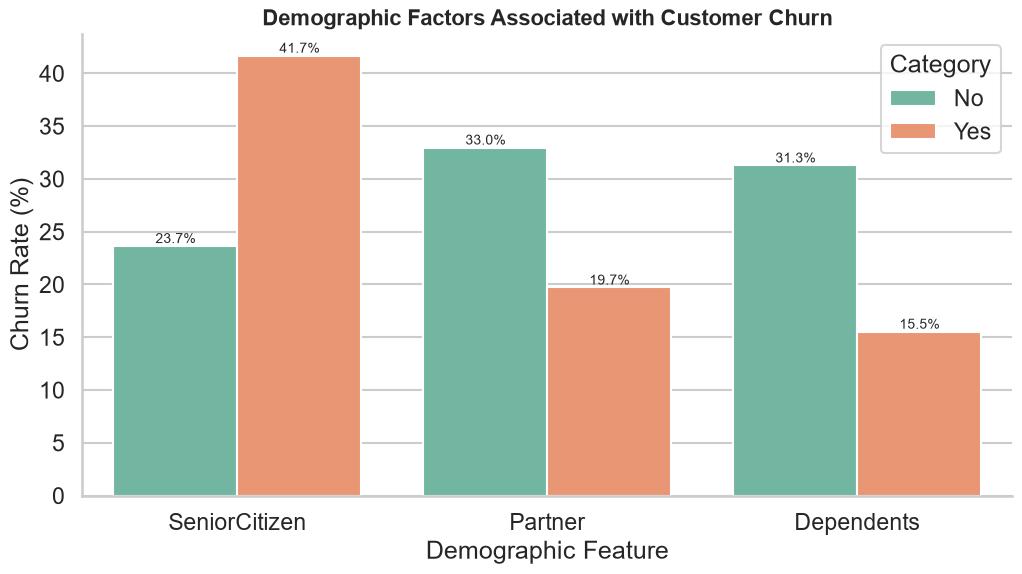

In [39]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=demographic_df,
    x='Feature',
    y='Churn Rate (%)',
    hue='Category',
    palette='Set2'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        fontsize=10
    )

plt.title(
    'Demographic Factors Associated with Customer Churn',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Demographic Feature')

plt.ylabel('Churn Rate (%)')

plt.legend(
    title='Category'
)

sns.despine()

plt.show()

### Summary Table

In [40]:
demographic_df.pivot(
    index='Feature',
    columns='Category',
    values='Churn Rate (%)'
).round(2)

Category,No,Yes
Feature,,
Dependents,31.28,15.53
Partner,32.98,19.72
SeniorCitizen,23.65,41.68


### Business Insight

- Senior citizens demonstrate relatively higher churn rates compared to non-senior customers.
- Customers without partners or dependents exhibit increased churn propensity.
- Household composition may influence customer stability and long-term service commitment.

## 2.10 Service Add-On Impact Analysis

In [41]:
service_features = [
    'OnlineSecurity',
    'TechSupport',
    'DeviceProtection',
    'OnlineBackup',
    'StreamingTV',
    'StreamingMovies'
]

### Calculate Churn Rates

In [42]:
service_results = []

for feature in service_features:

    risk = (
        df.groupby(feature)['Churn']
          .apply(lambda x: (x == 'Yes').mean() * 100)
          .reset_index()
    )

    risk.columns = [
        'Category',
        'Churn Rate (%)'
    ]

    risk['Feature'] = feature

    service_results.append(risk)

service_df = pd.concat(
    service_results,
    ignore_index=True
)

### Remove "No internet service"

In [43]:
service_df = service_df[
    service_df['Category'] != 'No internet service'
]

### Visualization

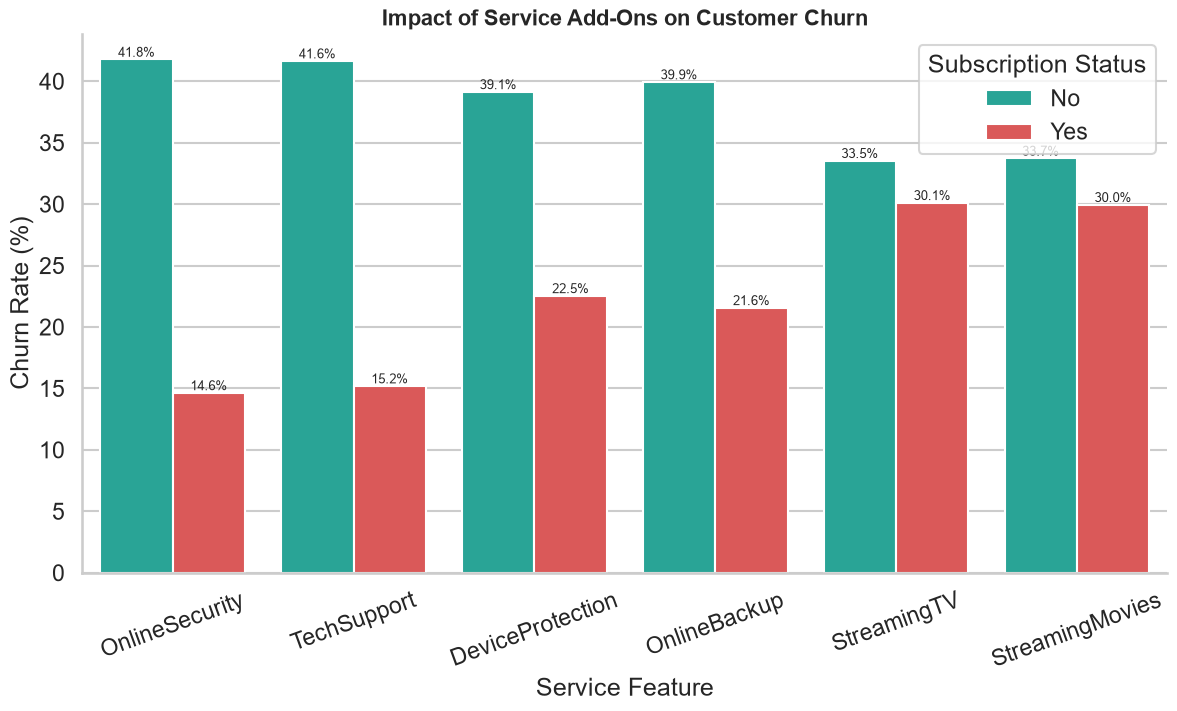

In [44]:
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=service_df,
    x='Feature',
    y='Churn Rate (%)',
    hue='Category',
    palette=['#14b8a6', '#ef4444']
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        fontsize=9
    )

plt.title(
    'Impact of Service Add-Ons on Customer Churn',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Service Feature')

plt.ylabel('Churn Rate (%)')

plt.legend(
    title='Subscription Status'
)

plt.xticks(rotation=20)

sns.despine()

plt.show()

### High-Risk Segments

In [45]:
high_risk = (
    service_df[
        service_df['Category'] == 'No'
    ]
    .sort_values(
        'Churn Rate (%)',
        ascending=False
    )
)

display(
    high_risk.round(2)
)

,Category,Churn Rate (%),Feature
0,No,41.78,OnlineSecurity
3,No,41.65,TechSupport
9,No,39.94,OnlineBackup
6,No,39.14,DeviceProtection
15,No,33.73,StreamingMovies
12,No,33.54,StreamingTV


### Business Insight

- Customers lacking **Online Security** and **Technical Support** demonstrate substantially higher churn rates.
- Service add-ons appear to strengthen customer engagement and increase switching costs.
- Organizations should consider promoting support-related services as part of their retention strategy.

# 3. Feature Engineering

Feature engineering transforms raw customer information into a structured format suitable for machine learning algorithms.

The following preprocessing steps were performed:

- Removal of non-predictive identifiers.
- Encoding of categorical variables.
- Feature scaling where appropriate.
- Preparation of datasets for model training and evaluation.

## 3.1 Remove Non-Predictive Features

Customer identifiers uniquely distinguish records but do not contribute to churn prediction.

In [46]:
# Create modeling dataset
df_model = df.copy()

# Remove EDA-specific columns
eda_columns = [
    'Tenure Group',
    'Charge Tier',
    'Tenure Cohort',
    'Pricing Tier'
]

df_model = df_model.drop(
    columns=eda_columns,
    errors='ignore'
)

# Remove identifier column
df_model = df_model.drop(
    'customerID',
    axis=1
)

## 3.2 Separate Features and Target Variable

In [47]:
X = df_model.drop(
    'Churn',
    axis=1
)

y = df_model['Churn']

In [48]:
print(
    "Remaining categorical columns:"
)

print(
    X.select_dtypes(
        include=['category']
    ).columns.tolist()
)

Remaining categorical columns:
[]


## 3.3 Encode Target Variable

The target variable was transformed into binary format for supervised learning.

In [49]:
le = LabelEncoder()

y = le.fit_transform(y)

print(
    "Target Classes:",
    le.classes_
)

Target Classes: ['No' 'Yes']


## 3.4 Identify Numerical and Categorical Features

In [50]:
categorical_cols = (
    X.select_dtypes(
        include=['object']
    )
    .columns
)

numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

print(
    f"Categorical Features: {len(categorical_cols)}"
)

print(
    f"Numerical Features: {len(numerical_cols)}"
)

Categorical Features: 15
Numerical Features: 3


## 3.5 Encode Categorical Features

Categorical variables were transformed using one-hot encoding to ensure compatibility with machine learning algorithms.

In [51]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

## 3.6 Train-Test Split

The dataset was divided into training and testing subsets while preserving the original churn distribution.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## 3.7 Feature Scaling

Numerical variables were standardized to improve the performance of distance-based and linear models.

In [53]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()

X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test_scaled[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

## 3.8 Prepared Dataset Summary

In [54]:
summary = pd.DataFrame({
    'Dataset': [
        'Training Set',
        'Testing Set'
    ],
    'Rows': [
        X_train.shape[0],
        X_test.shape[0]
    ],
    'Features': [
        X_train.shape[1],
        X_test.shape[1]
    ]
})

display(summary)

,Dataset,Rows,Features
0,Training Set,5625,30
1,Testing Set,1407,30


In [55]:
print(
    f"Total Engineered Features: "
    f"{X.shape[1]}"
)

print(
    f"Positive Class Ratio: "
    f"{(y.mean()*100):.2f}%"
)

Total Engineered Features: 30
Positive Class Ratio: 26.58%


### Feature Engineering Summary

- Customer identifiers were removed to prevent data leakage.
- Categorical attributes were encoded using one-hot encoding.
- Numerical variables were standardized to improve model performance.
- Stratified sampling ensured consistent class distributions across training and testing datasets.

---
# 4. Model Development

This section evaluates multiple machine learning algorithms for customer churn prediction. The objective is to identify the model that best balances predictive performance and business interpretability.

The following models were considered:

- Logistic Regression
- Random Forest Classifier
- Extreme Gradient Boosting (XGBoost)

Performance was assessed using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

## 4.1 Model Evaluation Framework

To ensure a comprehensive assessment of model effectiveness, multiple evaluation metrics were considered.

- **Accuracy:** Overall prediction correctness.
- **Precision:** Ability to correctly identify churners.
- **Recall:** Ability to capture actual churners.
- **F1-Score:** Balance between precision and recall.
- **ROC-AUC:** Overall discriminatory power across thresholds.

In [56]:
results = []
trained_models = {}

def evaluate_model(
    y_true,
    y_pred,
    y_pred_proba,
    model_name,
    model
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_true,
        y_pred_proba
    )

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    })

    trained_models[model_name] = model

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(6, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['No Churn', 'Churn'],
        yticklabels=['No Churn', 'Churn']
    )

    plt.title(
        f'{model_name} Confusion Matrix',
        fontweight='bold'
    )

    plt.show()

## 4.2 Logistic Regression

Logistic Regression serves as a baseline model due to its simplicity, interpretability, and effectiveness in binary classification problems.

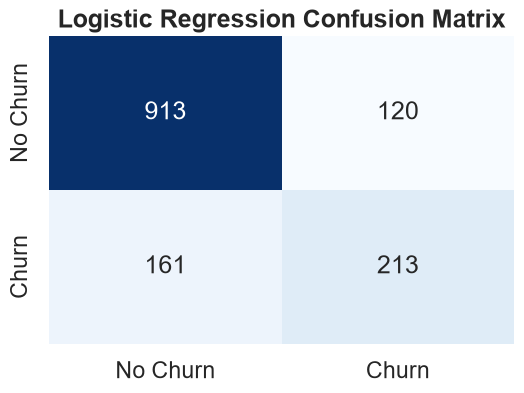

In [57]:
lr = LogisticRegression(
    random_state=42
)

lr.fit(
    X_train,
    y_train
)

y_pred_lr = lr.predict(
    X_test
)

y_pred_proba_lr = (
    lr.predict_proba(X_test)[:, 1]
)

evaluate_model(
    y_test,
    y_pred_lr,
    y_pred_proba_lr,
    "Logistic Regression",
    lr
)

## 4.3 Random Forest

Random Forest is an ensemble learning algorithm capable of capturing complex, non-linear relationships among customer attributes.

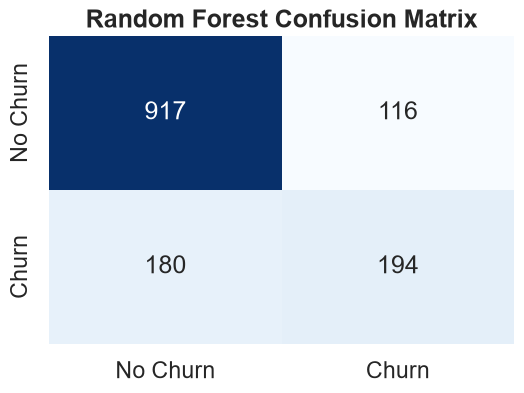

In [58]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf.fit(
    X_train,
    y_train
)

y_pred_rf = rf.predict(
    X_test
)

y_pred_proba_rf = (
    rf.predict_proba(X_test)[:, 1]
)

evaluate_model(
    y_test,
    y_pred_rf,
    y_pred_proba_rf,
    "Random Forest",
    rf
)

## 4.4 XGBoost

Extreme Gradient Boosting (XGBoost) is a powerful boosting algorithm frequently used in structured data problems due to its superior predictive capabilities.

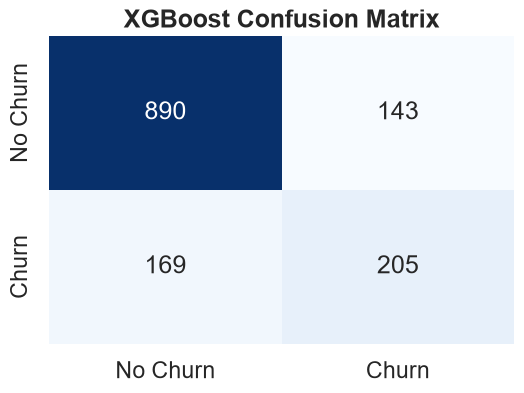

In [59]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(
    X_train,
    y_train
)

y_pred_xgb = xgb.predict(
    X_test
)

y_pred_proba_xgb = (
    xgb.predict_proba(X_test)[:, 1]
)

evaluate_model(
    y_test,
    y_pred_xgb,
    y_pred_proba_xgb,
    "XGBoost",
    xgb
)

# 5. Model Comparison

Selecting the most appropriate model requires balancing predictive performance with interpretability and business requirements.

The following table summarizes the performance of all evaluated algorithms.

In [60]:
results_df = pd.DataFrame(
    results
)

display(
    results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8003,0.6396,0.5695,0.6025,0.8365
1,Random Forest,0.7896,0.6258,0.5187,0.5673,0.8165
2,XGBoost,0.7783,0.5891,0.5481,0.5679,0.8197


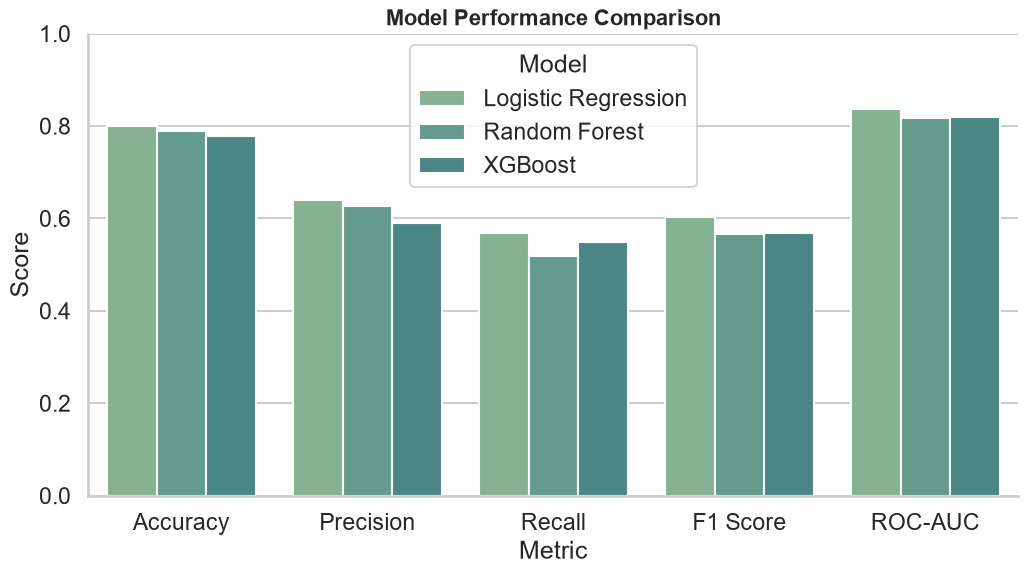

In [61]:
comparison = results_df.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison,
    x='Metric',
    y='Score',
    hue='Model'
)

plt.title(
    'Model Performance Comparison',
    fontsize=16,
    fontweight='bold'
)

plt.ylim(0, 1)

plt.show()

In [62]:
best_model_name = (
    results_df
    .sort_values(
        'ROC-AUC',
        ascending=False
    )
    .iloc[0]['Model']
)

best_model = trained_models[
    best_model_name
]

print(
    f"Best Model: {best_model_name}"
)

Best Model: Logistic Regression


---
# 6. ROC Curve Analysis

ROC curves illustrate the trade-off between sensitivity and specificity across various classification thresholds.

Models with higher AUC values demonstrate superior discriminatory performance.

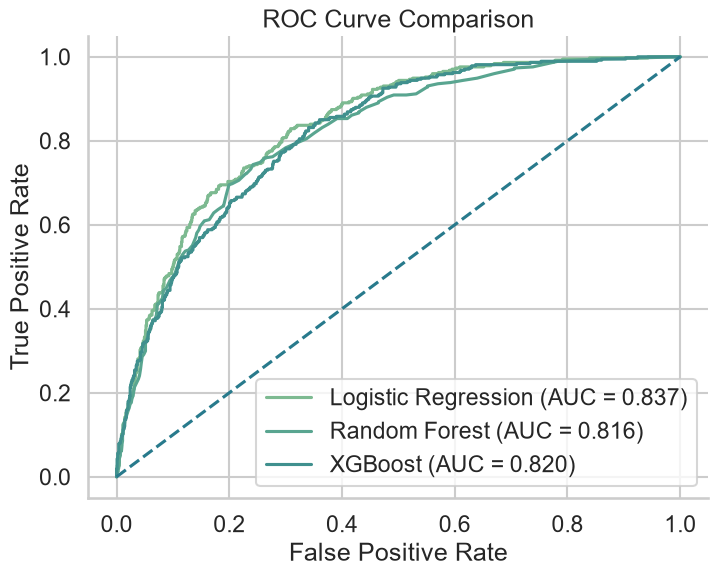

In [63]:
plt.figure(figsize=(8, 6))

for name, probs in [

    ('Logistic Regression', y_pred_proba_lr),

    ('Random Forest', y_pred_proba_rf),

    ('XGBoost', y_pred_proba_xgb)

]:

    fpr, tpr, _ = roc_curve(
        y_test,
        probs
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f'{name} (AUC = {roc_auc:.3f})'
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel(
    'False Positive Rate'
)

plt.ylabel(
    'True Positive Rate'
)

plt.title(
    'ROC Curve Comparison'
)

plt.legend()

plt.show()

---
# 7. Feature Importance Analysis

Understanding the primary drivers of churn is essential for translating predictive insights into business actions.

Feature importance analysis identifies the customer attributes contributing most significantly to churn predictions.

In [64]:
if hasattr(
    best_model,
    'feature_importances_'
):

    importance = (
        best_model
        .feature_importances_
    )

elif hasattr(
    best_model,
    'coef_'
):

    importance = np.abs(
        best_model.coef_[0]
    )

else:

    importance = None

,Feature,Importance
25,Contract_Two year,0.694020
13,OnlineSecurity_Yes,0.609439
19,TechSupport_Yes,0.580134
10,InternetService_Fiber optic,0.576745
24,Contract_One year,0.500026
7,PhoneService_Yes,0.468236
26,PaperlessBilling_Yes,0.362412
8,MultipleLines_No phone service,0.289346
9,MultipleLines_Yes,0.270458
15,OnlineBackup_Yes,0.261811


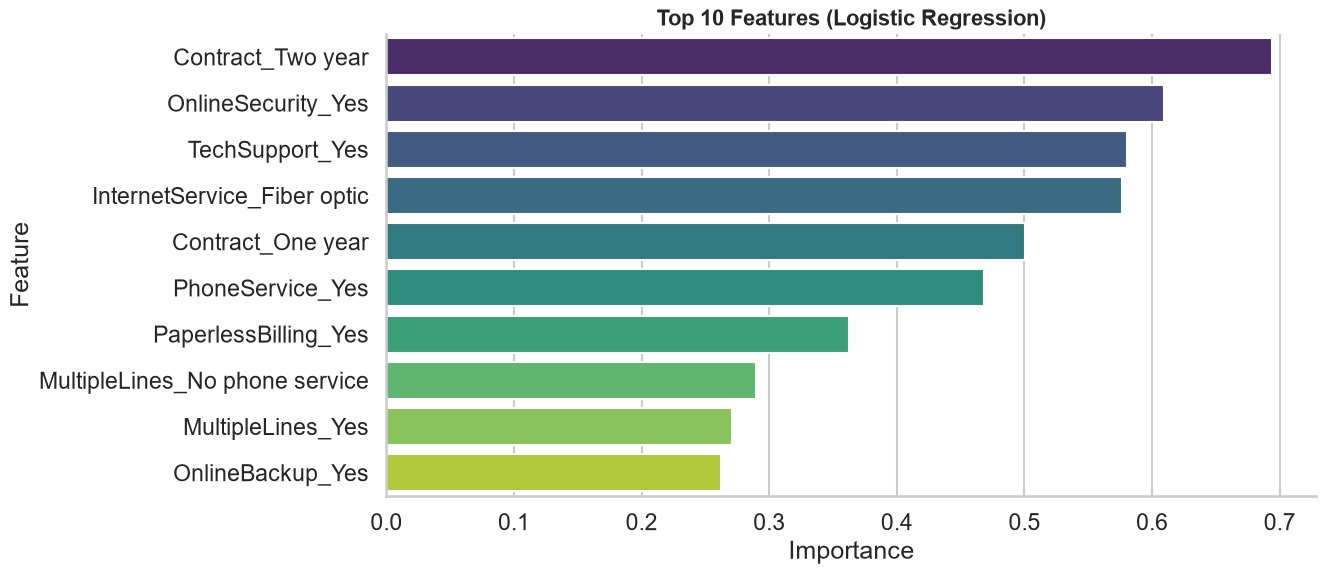

In [65]:
if importance is not None:

    feat_importance = pd.DataFrame({

        'Feature':
        X_train.columns,

        'Importance':
        importance

    })

    feat_importance = (
        feat_importance
        .sort_values(
            'Importance',
            ascending=False
        )
        .head(10)
    )

    display(
        feat_importance
    )

    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=feat_importance,
        x='Importance',
        y='Feature',
        palette='viridis'
    )

    plt.title(
        f'Top 10 Features ({best_model_name})',
        fontsize=16,
        fontweight='bold'
    )

    plt.show()

---
## 8. Business Recommendations

Based on the analytical findings and predictive modeling outcomes, the following recommendations are proposed to mitigate customer churn.

## Recommended Actions

### 1. Strengthen Early Customer Engagement
- Implement proactive onboarding initiatives during the first year of the customer lifecycle.

### 2. Promote Long-Term Contracts
- Encourage migration from month-to-month plans through targeted incentives.

### 3. Prioritize High-Value Customers
- Closely monitor premium subscribers exhibiting elevated churn risk.

### 4. Improve Fiber Optic Customer Experience
- Investigate service-related concerns among fiber optic customers.

### 5. Encourage Adoption of Support Services
- Promote Online Security and Technical Support offerings to enhance customer stickiness.

### 6. Modernize Payment Behavior
- Transition Electronic Check users toward automated payment alternatives.

### 7. Deploy Predictive Retention Programs
- Utilize the selected machine learning model to identify high-risk customers and trigger personalized retention interventions.

# 9. Conclusion

This project demonstrated the application of machine learning techniques to predict customer churn and uncover the underlying factors influencing customer attrition.

Key findings highlighted the importance of contract type, tenure, payment methods, service adoption, and pricing in shaping customer retention behavior.

Among the evaluated models, the selected approach provided strong predictive performance and may support proactive retention initiatives through early identification of high-risk customers.

Future work may include hyperparameter optimization, explainable AI techniques such as SHAP, and deployment through interactive dashboards.